# import libraries and data

In [1]:
import numpy as np 
import pandas as pd 
import orjson
from matplotlib import pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os
import seaborn as sns

In [2]:
track1 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track1_train.json')
track2 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track2_train.json')
global track1 
global track2

In [3]:
track1.head()

,patient_id,left,right
0,1,"{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ...","{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ..."
1,2,"{'1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
2,3,"{'1': 0, '2': 1, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
3,6,"{'1': 1, '2': 1, '3': 0, '4': 1, '5': 0, '6': ...","{'1': 0, '2': 0, '3': 0, '4': 1, '5': 0, '6': ..."
4,7,"{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."


In [4]:
track2.head()

,patient_id,left,right
0,1,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
1,5,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
2,12,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
3,18,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}
4,21,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}


# Metadata Preprocessing & EDA

In [5]:
def processing_metadata(track1 = track1, track2 = track2):
    for i in range(1, 18):
        track1['L'+str(i)] = track1['left'].apply(lambda x: x[str(i)])
        track1['R'+str(i)] = track1['right'].apply(lambda x: x[str(i)])
    track1_scored_item = ['L']
    track1 = track1.drop(['left', 'right'], axis=1)
    track2['Left_gait_subtype'] = track2['left'].map(lambda x: x['gait_subtype'])
    track2['Right_gait_subtype'] = track2['right'].map(lambda x: x['gait_subtype'])
    track2 = track2.drop(['left', 'right'], axis = 1)
    return track1, track2

In [6]:
track1, track2 = processing_metadata()
track1.head()

,patient_id,L1,R1,L2,R2,L3,R3,L4,R4,L5,...,L13,R13,L14,R14,L15,R15,L16,R16,L17,R17
0,1,0,0,1,1,0,0,1,1,1,...,0,0,1,0,1,1,1,1,0,0
1,2,0,1,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,3,0,1,1,1,0,0,0,0,0,...,0,0,0,1,1,0,1,1,0,1
3,6,1,0,1,0,0,0,1,1,0,...,0,0,0,0,1,1,0,1,0,0
4,7,1,1,1,1,0,0,0,0,1,...,0,0,1,0,1,1,1,1,1,1


In [7]:
track2.head()

,patient_id,Left_gait_subtype,Right_gait_subtype
0,1,type3,type3
1,5,type3,type3
2,12,type3,type3
3,18,type2,type2
4,21,type2,type2


# Q1: how many patients do we have

In [8]:
print(track1.shape[0])
print(track2.shape[0])

94
22


## Q2: do patients have the same gait type at left and right?

In [9]:
track2.loc[track2['Left_gait_subtype']!=track2['Right_gait_subtype']]

,patient_id,Left_gait_subtype,Right_gait_subtype
11,32,type2,type3
15,48,type1,type3


## Q3: how many patients have left EVGS scoring different from their right?

In [10]:
def sum_svgs_per_leg(track1 = track1):
    left = ['L'+str(i) for i in range(1, 18)]
    right = ['R'+str(i) for i in range(1, 18)]
    track1['Left_SVGS_Score'] = track1.loc[:,left].sum(axis = 1)
    track1['Right_SVGS_Score'] = track1.loc[:,right].sum(axis = 1)
    return track1

In [11]:
track1 = sum_svgs_per_leg()

In [12]:
track1[['Left_SVGS_Score', 'Right_SVGS_Score']].describe()

,Left_SVGS_Score,Right_SVGS_Score
count,94.000000,94.000000
mean,5.840426,5.989362
std,3.312742,3.227885
min,1.000000,0.000000
25%,3.000000,3.000000
50%,5.000000,6.000000
75%,8.000000,8.000000
max,13.000000,14.000000


In [13]:
def get_id(s):
    num = 0
    for i in range(-1, -len(s)-1, -1):
        num+=10**(-i-1)*int(s[i])
    return(num)

In [14]:
# Define points2keep and cols outside so they are accessible
POINTS2KEEP = [1, 6, 7, 12, 13, 14, 15, 16, 17, 18, 21, 19, 22, 20, 23]
COLS = ['patient_id','frame', 'nose', 'shoulder_l', 'shoulder_r', 'hip_l', 'hip_r', 'knee_l', 'knee_r', 'ankle_l', 
        'ankle_r', 'toe1_l', 'toe1_r', 'toe5_l', 'toe5_r', 'heel_l', 'heel_r', 'nose_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI', 'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI',
        'toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 'heel_l_CI', 'heel_r_CI', 'bbox']

def process_file(frame_path):
    try:
        # Extract patient_id from the path (e.g., .../dataset/001/front/...)
        patient_id = frame_path.parts[-3] 
        frame = frame_path.parts[-1].split('.')[0].split('_')[1]
        
        with open(frame_path, 'r') as f:
            data = orjson.loads(f.read())
            inst = data['instance_info'][0]
            
            kp = inst['keypoints']
            ks = inst['keypoint_scores']
            bbox = inst.get('gt_bbox_xywh_px')
            
            record = [get_id(patient_id), get_id(frame)+1]
            record.extend([kp[idx-1] for idx in POINTS2KEEP])
            record.extend([ks[idx-1] for idx in POINTS2KEEP])
            record.append(bbox)
            return record
    except Exception as e:
        pass
        
def organize_df_parallel(side_filter):
    base_path = Path(r'/kaggle/input/datasets/adastroabyssosque/first-ai-for-children-competition-data/dataset/')
    
    print("Scanning for files...")
    # Get only the files that match your side filter
    all_frames = [f for f in base_path.rglob("*.json") if side_filter in f.parent.name.lower()]
    
    #print(f"Starting parallel processing of {len(all_frames)} files...")
    
    # ProcessPoolExecutor automatically uses all available CPU cores
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_file, all_frames))
    
    # Filter out None results from errors and create DataFrame
    clean_results = [r for r in results if r is not None]
    return pd.DataFrame(clean_results, columns=COLS).sort_values(by = ['patient_id', 'frame'])

# Run it!
print('Gathering points from front view...')
front_df = organize_df_parallel('forward')
print('Gathering points from back veiw...')
back_df = organize_df_parallel('backward')
print('Gathering points from left view...')
left_df = organize_df_parallel('left')
print('Gathering points from right view...')
right_df = organize_df_parallel('right')

print(front_df.shape)
print(back_df.shape)
print(left_df.shape)
print(right_df.shape)

Gathering points from front view...
Scanning for files...
Gathering points from back veiw...
Scanning for files...
Gathering points from left view...
Scanning for files...
Gathering points from right view...
Scanning for files...
(90107, 33)
(83560, 33)
(88235, 33)
(77240, 33)


In [15]:
CI = [ 'nose_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI', 'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI',
        'toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 'heel_l_CI', 'heel_r_CI']
front_df[CI].describe()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
count,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000,90107.000000
mean,0.861224,0.923259,0.933210,0.804220,0.802808,0.917549,0.931869,0.897908,0.911986,0.950530,0.953823,0.937484,0.978886,0.900059,0.922741
std,0.094449,0.068488,0.068797,0.081197,0.073783,0.087215,0.084441,0.073907,0.067893,0.076953,0.072436,0.068173,0.066799,0.082403,0.080971
min,0.013861,0.032449,0.030224,0.039362,0.039672,0.077913,0.054910,0.058995,0.070465,0.044454,0.036199,0.048317,0.075365,0.041988,0.050227
25%,0.824981,0.909310,0.920636,0.773760,0.773866,0.907442,0.921668,0.882965,0.894334,0.927790,0.937243,0.919455,0.963546,0.873065,0.894326
50%,0.877955,0.935219,0.948950,0.816805,0.812121,0.938180,0.952207,0.913496,0.924306,0.962797,0.966208,0.949364,0.990774,0.912953,0.937441
75%,0.919839,0.957206,0.968940,0.852118,0.846661,0.962820,0.975803,0.937932,0.948891,0.991949,0.992009,0.974599,1.014266,0.948334,0.971661
max,1.089543,1.092138,1.076687,1.006824,1.017301,1.077597,1.092695,1.087008,1.091528,1.182627,1.154223,1.161131,1.224737,1.168087,1.196089


In [16]:
back_df[CI].describe()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
count,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000,83560.000000
mean,0.746907,0.922719,0.897648,0.768674,0.763712,0.880952,0.876098,0.875260,0.891916,0.848509,0.870137,0.906087,0.941512,0.914176,0.906729
std,0.144237,0.060073,0.066766,0.068255,0.070298,0.082818,0.086202,0.081763,0.083781,0.097126,0.099721,0.097545,0.101222,0.094515,0.105344
min,0.061416,0.035314,0.046902,0.047720,0.036939,0.037483,0.064336,0.060504,0.051798,0.032214,0.047376,0.033499,0.032071,0.029868,0.032662
25%,0.684086,0.903367,0.876321,0.735709,0.728165,0.861812,0.851563,0.854826,0.870322,0.802219,0.820539,0.864645,0.900543,0.876348,0.858765
50%,0.783016,0.934090,0.910030,0.775475,0.770305,0.895235,0.890602,0.889657,0.908800,0.862351,0.883060,0.923289,0.954939,0.930249,0.920364
75%,0.843165,0.957425,0.936820,0.811879,0.809540,0.924359,0.924866,0.920116,0.939059,0.910852,0.936098,0.969202,1.003428,0.973181,0.974882
max,1.068371,1.125461,1.073316,0.991911,0.985990,1.066619,1.073803,1.076378,1.120733,1.151120,1.179143,1.175943,1.243794,1.198495,1.251318


In [17]:
left_df[CI].describe()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
count,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000,88235.000000
mean,0.903315,0.949752,0.894621,0.811679,0.774671,0.904467,0.904042,0.917078,0.933054,0.923591,0.954246,0.956772,0.965169,0.931515,0.946258
std,0.085756,0.073014,0.077773,0.074745,0.076797,0.069504,0.087982,0.068860,0.079621,0.073459,0.099389,0.083255,0.097207,0.076043,0.091283
min,0.046999,0.042107,0.050104,0.030148,0.037359,0.074731,0.053502,0.063228,0.063479,0.039191,0.021844,0.034895,0.021581,0.044906,0.040335
25%,0.884024,0.934200,0.872316,0.779544,0.737500,0.888375,0.882224,0.898276,0.915544,0.900668,0.934345,0.932827,0.947616,0.906625,0.924010
50%,0.920045,0.957580,0.905844,0.815757,0.779663,0.913664,0.920325,0.924842,0.949226,0.932704,0.977036,0.973572,0.985653,0.937713,0.960055
75%,0.948011,0.980024,0.934965,0.852939,0.822047,0.936796,0.951756,0.950085,0.974711,0.960839,1.008693,1.002408,1.015988,0.968792,0.992094
max,1.187838,1.113153,1.093108,1.067415,1.018631,1.095921,1.124323,1.101095,1.183114,1.176044,1.207214,1.170830,1.203580,1.191274,1.275649


In [18]:
right_df[CI].describe()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
count,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000,77240.000000
mean,0.928211,0.913149,0.954952,0.771639,0.807267,0.903390,0.922504,0.921391,0.927213,0.952782,0.924960,0.922508,0.982291,0.954137,0.951924
std,0.073093,0.063972,0.049677,0.067205,0.065782,0.067757,0.060631,0.067173,0.064557,0.095964,0.072787,0.088957,0.081004,0.081762,0.071067
min,0.012190,0.072916,0.097015,0.043540,0.073025,0.102697,0.126434,0.082586,0.096141,0.039640,0.029130,0.045360,0.019610,0.035681,0.039809
25%,0.911276,0.885715,0.935368,0.732774,0.769753,0.880701,0.901057,0.905210,0.907648,0.925064,0.906968,0.892450,0.954813,0.933182,0.924869
50%,0.940823,0.919563,0.957877,0.774573,0.808942,0.914734,0.930753,0.933682,0.935856,0.965651,0.935302,0.935336,0.996454,0.965652,0.957656
75%,0.965984,0.950768,0.980716,0.814329,0.848041,0.943225,0.956915,0.956575,0.960732,1.003390,0.960439,0.971530,1.028699,0.994696,0.989999
max,1.110453,1.122550,1.135842,1.013056,1.097387,1.116956,1.128194,1.113308,1.117011,1.248153,1.152991,1.247655,1.210324,1.171622,1.203964


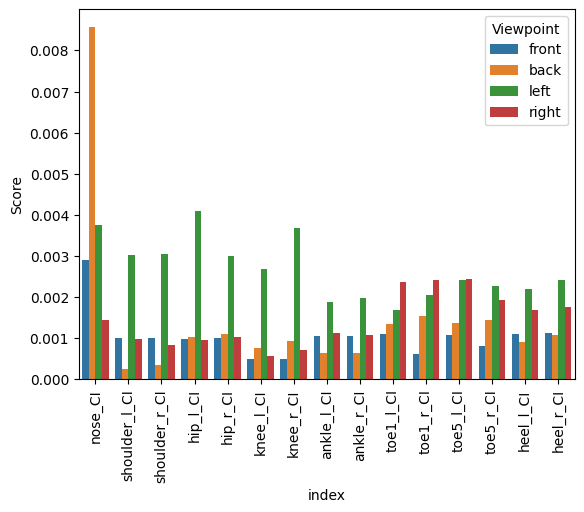

In [62]:
front_invalid = (front_df[CI]<0.3).sum()/front_df.shape[0]
back_invalid = (back_df[CI]<0.3).sum()/back_df.shape[0]
left_invalid = (left_df[CI]<0.3).sum()/left_df.shape[0]
right_invalid = (right_df[CI]<0.3).sum()/right_df.shape[0]
invalid_df = pd.concat([front_invalid, back_invalid, left_invalid, right_invalid], axis = 1, keys = ['front', 'back', 'left', 'right'])
invalid_df_melted = invalid_df.reset_index().melt(id_vars='index', var_name='Viewpoint', value_name='Score')
sns.barplot(data=invalid_df_melted, x='index', y='Score', hue='Viewpoint')
plt.xticks(rotation = 90)
plt.show()

In [21]:
print(front_df.shape[0]+back_df.shape[0]+left_df.shape[0]+right_df.shape[0])

339142


In [22]:
T1 = [4, 5, 18, 26, 28, 40, 42, 43, 47, 48, 53, 54, 72, 78, 83, 85]
T2 = [4, 6, 7, 13, 26, 35, 39, 42, 50]

test_t1_front = front_df.loc[front_df['patient_id'].isin(T1)]
test_t1_back = back_df.loc[back_df['patient_id'].isin(T1)]
test_t1_left = left_df.loc[left_df['patient_id'].isin(T1)]
test_t1_right = right_df.loc[left_df['patient_id'].isin(T1)]
test_t2_front = front_df.loc[front_df['patient_id'].isin(T2)]
test_t2_back = back_df.loc[back_df['patient_id'].isin(T2)]
test_t2_left = left_df.loc[left_df['patient_id'].isin(T2)]
test_t2_right = right_df.loc[left_df['patient_id'].isin(T2)]

print('T1 data shape in test T1: ')
print(f'Front: {test_t1_front.shape}')
print(f'Back: {test_t1_back.shape}')
print(f'Left: {test_t1_left.shape}')
print(f'Right: {test_t1_right.shape}')
print('T2 data shape in test T1: ')
print(f'Front: {test_t2_front.shape}')
print(f'Back: {test_t2_back.shape}')
print(f'Left: {test_t2_left.shape}')
print(f'Right: {test_t2_right.shape}')

train_t1_front = front_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_back = back_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_left = left_df.merge(track1, on = 'patient_id', how = 'inner')
train_t1_right = right_df.merge(track1, on = 'patient_id', how = 'inner')
train_t2_front = front_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_back = back_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_left = left_df.merge(track2, on = 'patient_id', how = 'inner')
train_t2_right = right_df.merge(track2, on = 'patient_id', how = 'inner')

print('T1 data shape in train T1: ')
print(f'Front: {train_t1_front.shape}')
print(f'Back: {train_t1_back.shape}')
print(f'Left: {train_t1_left.shape}')
print(f'Right: {train_t1_right.shape}')
print('T2 data shape in train T1: ')
print(f'Front: {train_t2_front.shape}')
print(f'Back: {train_t2_back.shape}')
print(f'Left: {train_t2_left.shape}')
print(f'Right: {train_t2_right.shape}')

T1 data shape in test T1: 
Front: (16464, 33)
Back: (12520, 33)
Left: (14485, 33)
Right: (14485, 33)
T2 data shape in test T1: 
Front: (8756, 33)
Back: (7321, 33)
Left: (8495, 33)
Right: (8495, 33)
T1 data shape in train T1: 
Front: (73643, 69)
Back: (71040, 69)
Left: (73750, 69)
Right: (64022, 69)
T2 data shape in train T1: 
Front: (18910, 35)
Back: (17440, 35)
Left: (15082, 35)
Right: (12017, 35)


In [38]:
corrupted = test_t1_front.loc[(test_t1_front['patient_id']==53) & (test_t1_front['frame']>1297)]
test_t1_front.drop(corrupted.index, inplace=True)

/tmp/ipykernel_55/2841214757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_t1_front.drop(corrupted.index, inplace=True)


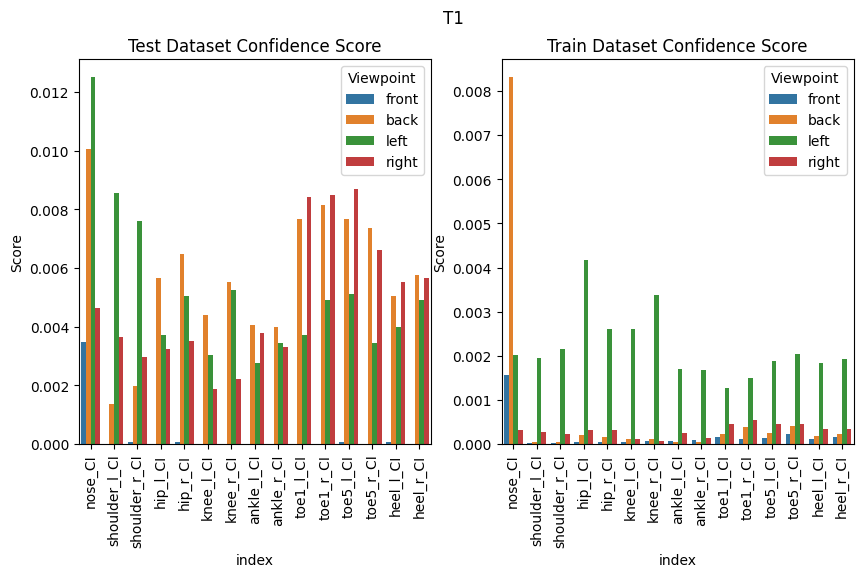

In [65]:
figx, ax = plt.subplots(1,2, figsize = (10, 5))
plt.suptitle('T1')
test_t1_front_invalid = (test_t1_front[CI]<0.3).sum()/test_t1_front.shape[0]
test_t1_back_invalid = (test_t1_back[CI]<0.3).sum()/test_t1_back.shape[0]
test_t1_left_invalid = (test_t1_left[CI]<0.3).sum()/test_t1_left.shape[0]
test_t1_right_invalid = (test_t1_right[CI]<0.3).sum()/test_t1_right.shape[0]
invalid_df_test = pd.concat([test_t1_front_invalid, test_t1_back_invalid, test_t1_left_invalid, test_t1_right_invalid], axis = 1, keys = ['front', 'back', 'left', 'right'])
invalid_df_test_melted = invalid_df_test.reset_index().melt(id_vars='index', var_name='Viewpoint', value_name='Score')
sns.barplot(data=invalid_df_test_melted, x='index', y='Score', hue='Viewpoint', ax = ax[0])
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_title('Test Dataset Confidence Score')

train_t1_front_invalid = (train_t1_front[CI]<0.3).sum()/train_t1_front.shape[0]
train_t1_back_invalid = (train_t1_back[CI]<0.3).sum()/train_t1_back.shape[0]
train_t1_left_invalid = (train_t1_left[CI]<0.3).sum()/train_t1_left.shape[0]
train_t1_right_invalid = (train_t1_right[CI]<0.3).sum()/train_t1_right.shape[0]
invalid_df_train = pd.concat([train_t1_front_invalid, train_t1_back_invalid, train_t1_left_invalid, train_t1_right_invalid], axis = 1, keys = ['front', 'back', 'left', 'right'])
invalid_df_train_melted = invalid_df_train.reset_index().melt(id_vars='index', var_name='Viewpoint', value_name='Score')
sns.barplot(data=invalid_df_train_melted, x='index', y='Score', hue='Viewpoint', ax = ax[1])
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_title('Train Dataset Confidence Score')
plt.show()

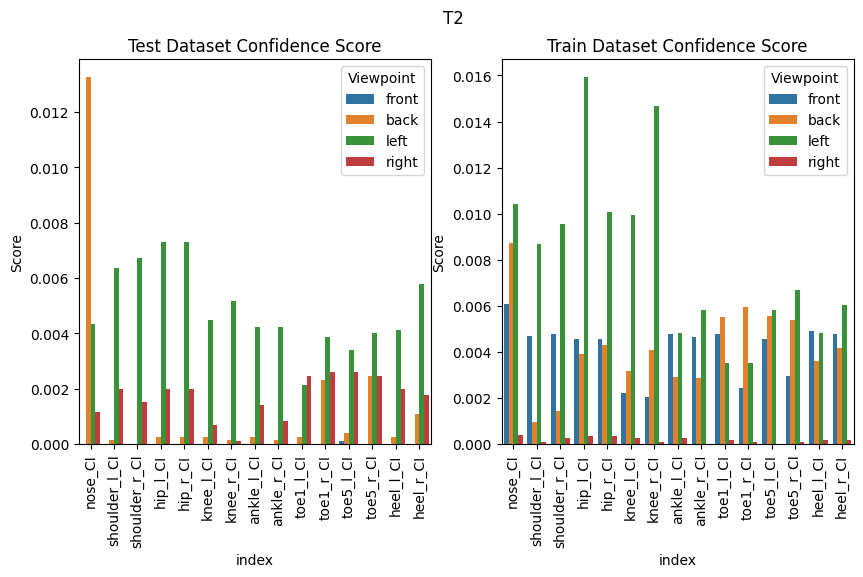

In [66]:
figx, ax = plt.subplots(1,2, figsize = (10, 5))
plt.suptitle('T2')
test_t2_front_invalid = (test_t2_front[CI]<0.3).sum()/test_t2_front.shape[0]
test_t2_back_invalid = (test_t2_back[CI]<0.3).sum()/test_t2_back.shape[0]
test_t2_left_invalid = (test_t2_left[CI]<0.3).sum()/test_t2_left.shape[0]
test_t2_right_invalid = (test_t2_right[CI]<0.3).sum()/test_t2_right.shape[0]
invalid_df_test = pd.concat([test_t2_front_invalid, test_t2_back_invalid, test_t2_left_invalid, test_t2_right_invalid], axis = 1, keys = ['front', 'back', 'left', 'right'])
invalid_df_test_melted = invalid_df_test.reset_index().melt(id_vars='index', var_name='Viewpoint', value_name='Score')
sns.barplot(data=invalid_df_test_melted, x='index', y='Score', hue='Viewpoint', ax = ax[0])
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_title('Test Dataset Confidence Score')

train_t2_front_invalid = (train_t2_front[CI]<0.3).sum()/train_t2_front.shape[0]
train_t2_back_invalid = (train_t2_back[CI]<0.3).sum()/train_t2_back.shape[0]
train_t2_left_invalid = (train_t2_left[CI]<0.3).sum()/train_t2_left.shape[0]
train_t2_right_invalid = (train_t2_right[CI]<0.3).sum()/train_t2_right.shape[0]
invalid_df_train = pd.concat([train_t2_front_invalid, train_t2_back_invalid, train_t2_left_invalid, train_t2_right_invalid], axis = 1, keys = ['front', 'back', 'left', 'right'])
invalid_df_train_melted = invalid_df_train.reset_index().melt(id_vars='index', var_name='Viewpoint', value_name='Score')
sns.barplot(data=invalid_df_train_melted, x='index', y='Score', hue='Viewpoint', ax = ax[1])
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_title('Train Dataset Confidence Score')
plt.show()

In [60]:
train_t2_front.groupby('Left_gait_subtype')[CI].mean()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
Left_gait_subtype,,,,,,,,,,,,,,,
WNL,0.901454,0.933688,0.963210,0.824037,0.823708,0.942772,0.949397,0.930811,0.937844,0.950234,0.947585,0.960545,0.981248,0.892090,0.928754
type1,0.860741,0.927240,0.951844,0.794584,0.791143,0.935486,0.953109,0.903269,0.918446,0.952776,0.956756,0.952083,0.990506,0.920191,0.939840
type2,0.859761,0.896631,0.910673,0.811444,0.807864,0.921395,0.923304,0.887736,0.893374,0.952863,0.944711,0.930760,0.983971,0.885798,0.908678
type3,0.841422,0.885666,0.901543,0.764986,0.765828,0.876060,0.896205,0.884980,0.889714,0.922933,0.945571,0.920173,0.958426,0.893854,0.909080
type4,0.855495,0.902465,0.896149,0.804975,0.766552,0.935312,0.924570,0.883632,0.901975,0.932319,0.918251,0.902021,0.963613,0.924005,0.921552


In [61]:
train_t2_front.groupby('Right_gait_subtype')[CI].mean()

,nose_CI,shoulder_l_CI,shoulder_r_CI,hip_l_CI,hip_r_CI,knee_l_CI,knee_r_CI,ankle_l_CI,ankle_r_CI,toe1_l_CI,toe1_r_CI,toe5_l_CI,toe5_r_CI,heel_l_CI,heel_r_CI
Right_gait_subtype,,,,,,,,,,,,,,,
WNL,0.901454,0.933688,0.963210,0.824037,0.823708,0.942772,0.949397,0.930811,0.937844,0.950234,0.947585,0.960545,0.981248,0.892090,0.928754
type1,0.867783,0.934185,0.955689,0.788022,0.782857,0.935197,0.955865,0.904124,0.913102,0.952921,0.958600,0.952730,0.992719,0.916013,0.940851
type2,0.865955,0.910536,0.930325,0.804235,0.799890,0.920710,0.923742,0.890569,0.892706,0.950374,0.943174,0.940882,0.988931,0.892500,0.906425
type3,0.838759,0.883110,0.900425,0.791112,0.792259,0.899905,0.912895,0.887747,0.903670,0.937094,0.947667,0.923424,0.965794,0.899549,0.917821
type4,0.855495,0.902465,0.896149,0.804975,0.766552,0.935312,0.924570,0.883632,0.901975,0.932319,0.918251,0.902021,0.963613,0.924005,0.921552
